In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score

from sklearn.model_selection import GridSearchCV



In [3]:
train = pd.read_csv("/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/train.csv")
test = pd.read_csv("/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1/test.csv")

train.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.0,1.50,1.0,N,212,237,Credit Card,5.0,6.533210,0.0,1.0,24.80,2.5,0.0
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.0,3.80,1.0,N,6,163,Credit Card,5.0,9.187048,0.0,1.0,31.55,2.5,0.0
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.0,1.89,1.0,N,35,81,Credit Card,2.5,6.793777,0.0,1.0,24.84,2.5,0.0
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.0,1.10,1.0,N,46,99,Credit Card,1.0,3.695121,0.0,1.0,13.45,2.5,0.0
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.0,2.84,1.0,N,213,114,Credit Card,2.5,7.838753,0.0,1.0,29.88,2.5,0.0


# Datatypes of columns

In [4]:
train.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type              object
extra                    float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
Airport_fee              float64
dtype: object

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount           10000 non-null  float64
 15  con

In [6]:
train.shape

(10000, 17)

In [7]:
train.sample(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
1915,1,2023-06-28 17:20:35,2023-06-28 17:19:54,1.0,0.50,1.0,N,20,216,Credit Card,2.5,3.907268,0.0,1.0,14.76,2.5,0.0
6899,1,2023-06-28 21:09:18,2023-06-28 22:29:23,1.0,1.64,1.0,N,1,263,Credit Card,1.0,3.574462,0.0,1.0,18.84,2.5,0.0
6168,0,2023-06-30 15:29:27,2023-06-30 15:49:53,1.0,1.20,1.0,N,24,261,Credit Card,5.0,6.862867,0.0,1.0,19.20,2.5,0.0
6614,1,2023-06-29 18:37:35,2023-06-29 18:12:16,1.0,14.11,1.0,N,1,260,Credit Card,2.5,2.436190,0.0,1.0,60.20,0.0,0.0
246,1,2023-06-29 06:44:43,2023-06-29 07:35:25,1.0,1.27,1.0,N,24,247,Credit Card,0.0,6.908038,0.0,1.0,16.70,2.5,0.0


# Descriptive statistics

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorID,10000.0,0.729100,0.444672,0.000000,0.000000,1.000000,1.000000,2.000000
passenger_count,9634.0,1.357276,0.883676,0.000000,1.000000,1.000000,1.000000,6.000000
trip_distance,10000.0,3.679527,4.905798,0.000000,1.070000,1.820000,3.630000,71.940000
RatecodeID,9634.0,1.450695,5.988978,1.000000,1.000000,1.000000,1.000000,99.000000
PULocationID,10000.0,132.710800,75.789597,1.000000,67.000000,133.000000,198.000000,264.000000
DOLocationID,10000.0,132.332400,75.959440,1.000000,68.000000,132.000000,199.000000,264.000000
extra,10000.0,1.940950,1.945885,-7.500000,0.000000,1.750000,2.500000,11.750000
tip_amount,10000.0,6.094658,4.438894,0.000713,3.466789,5.208233,7.455228,84.032617
tolls_amount,10000.0,0.664425,2.441070,-26.550000,0.000000,0.000000,0.000000,32.050000
improvement_surcharge,10000.0,0.979490,0.200076,-1.000000,1.000000,1.000000,1.000000,1.000000


# Handling missing values

In [9]:
train.isna().sum()

VendorID                   0
tpep_pickup_datetime       0
tpep_dropoff_datetime      0
passenger_count          366
trip_distance              0
RatecodeID               366
store_and_fwd_flag       366
PULocationID               0
DOLocationID               0
payment_type               0
extra                      0
tip_amount                 0
tolls_amount               0
improvement_surcharge      0
total_amount               0
congestion_surcharge     366
Airport_fee              366
dtype: int64

In [10]:
train.isna().sum().sum()

np.int64(1830)

passenger_count → Filled with the most common passenger count.

RatecodeID → Replaced with the most frequent rate code.

store_and_fwd_flag → Missing values replaced with the most common flag value (Y or N).
congestion_surcharge → Filled with the most common surcharge value.

Airport_fee → Missing values replaced with 0 because a missing value likely means no airport fee applied.

In [11]:
train['passenger_count'].fillna(train['passenger_count'].mode()[0], inplace=True)
train['RatecodeID'].fillna(train['RatecodeID'].mode()[0], inplace=True)
train['store_and_fwd_flag'].fillna(train['store_and_fwd_flag'].mode()[0], inplace=True)
train['congestion_surcharge'].fillna(train['congestion_surcharge'].mode()[0], inplace=True)
train['Airport_fee'].fillna(0, inplace=True)

/tmp/ipykernel_17/3237831365.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['passenger_count'].fillna(train['passenger_count'].mode()[0], inplace=True)
/tmp/ipykernel_17/3237831365.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

In [12]:
train.isnull().sum().sum()

np.int64(0)

# Duplicates

In [13]:
duplicates=train.duplicated().sum()
print("Duplicates:", duplicates)

Duplicates: 0


Since there are no duplicates present in dataset ,no rows were removed.

In [14]:
num_cols = train.select_dtypes(include=np.number).columns
cat_cols = train.select_dtypes(exclude=np.number).columns



# Outliers

In [15]:
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)}")

VendorID: 0
passenger_count: 2352
trip_distance: 1354
RatecodeID: 577
PULocationID: 0
DOLocationID: 0
extra: 242
tip_amount: 657
tolls_amount: 884
improvement_surcharge: 106
total_amount: 1343
congestion_surcharge: 923
Airport_fee: 909


Although outliers are detected using the IQR method, they are not removed from the dataset.

Reason for Retaining Outliers

The target variable in this problem is total_amount, which represents the total fare of a taxi trip. Larger trip distances, tolls, surcharges, or airport trips can naturally result in higher total amounts.

I experimented with removing negative outliers in the total_amount feature. However, the model performance dropped. This indicated that those values were meaningful in the dataset, so I retained them.

# Visualization

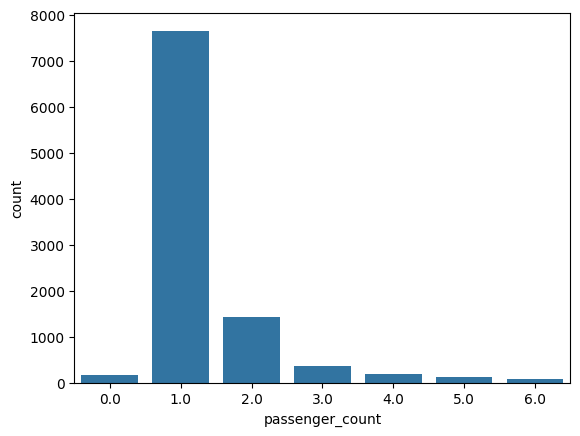

In [16]:
sns.countplot(x='passenger_count', data=train)
plt.show()

****Most of the passengers are individual.****

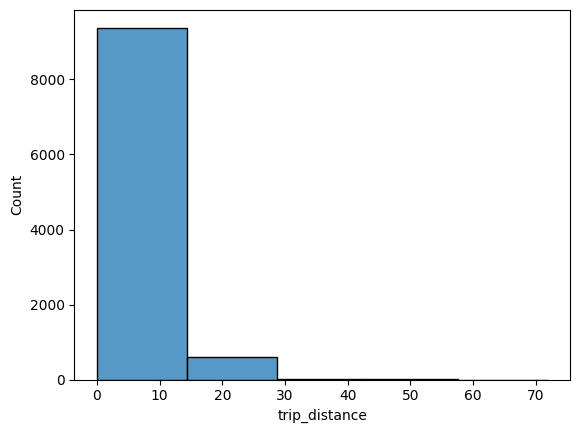

In [17]:
sns.histplot(train['trip_distance'], bins=5)
plt.show()


****Most of the trips are short distance,there are long distance trips very rarely****

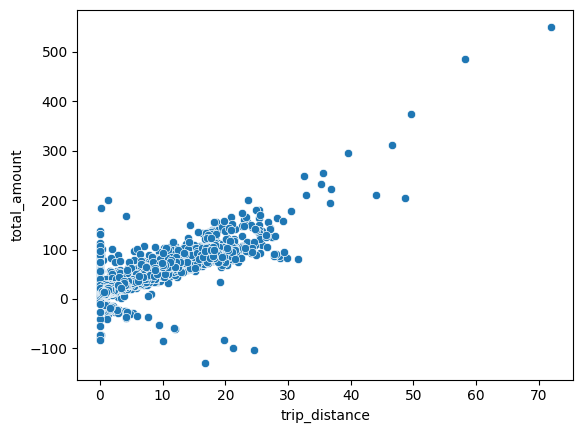

In [18]:
sns.scatterplot(x='trip_distance', y='total_amount', data=train)
plt.show()

****There is a positive relationship between total_amount and trip_distance.**** But there are some unusual points that are outliers.

In [19]:
X = train.drop(columns=['total_amount'])
y = train['total_amount']

In [20]:
num_cols=[col for col in num_cols if col != 'total_amount']

In [21]:
print(num_cols)

['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']


# Scaling and Encoding

Numerical columns are standardized using StandardScaler.

In [22]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

Categorical variables are converted into numerical indicator variables using OneHotEncoder, where each category is represented by a separate column containing 0 or 1.

In [23]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

 > Combining pipelines using Column Transformer

In [24]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

> Train Validation split

In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The preprocessor is fit on the training data.The same transformations are applied on validation data.

In [26]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)

# Models

To find the best model for predicting total_amount, several regression models were trained and compared.

In [27]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "GradientBoosting":GradientBoostingRegressor(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "AdaBoost": AdaBoostRegressor()
}

In [28]:
results = {}

for name, model in models.items():
    
    model.fit(X_train_transformed, y_train)
    
    preds = model.predict(X_val_transformed)
    
    score = r2_score(y_val, preds)
    
    results[name] = score

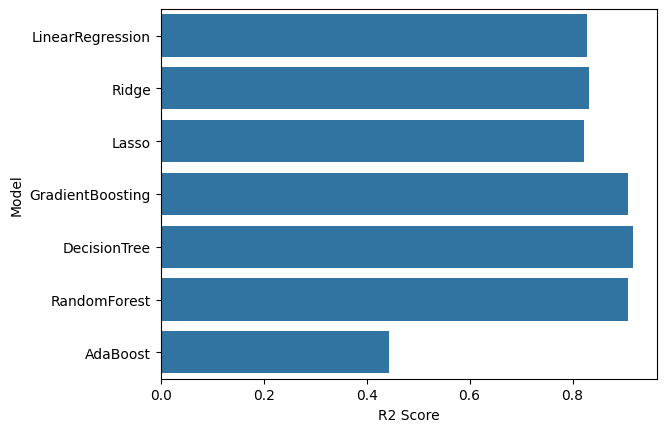

In [29]:
results_df = pd.DataFrame(results.items(), columns=["Model","R2 Score"])

results_df.sort_values(by="R2 Score", ascending=False)
sns.barplot(x="R2 Score", y="Model", data=results_df)
plt.show()

In [30]:
results_df = pd.DataFrame(results.items(), columns=["Model","R2 Score"])

results_df.sort_values(by="R2 Score", ascending=False)


,Model,R2 Score
4,DecisionTree,0.917474
5,RandomForest,0.908114
3,GradientBoosting,0.907997
1,Ridge,0.831279
0,LinearRegression,0.828805
2,Lasso,0.821570
6,AdaBoost,0.444183


The best models are DecisionTree,GradientBoosting,RandomForest

# Hyperparameter Tuning

In [31]:


dt_params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(),
    dt_params,
    cv=5,
    scoring="r2"
)

dt_grid.fit(X_train_transformed, y_train)
print("Best DecisionTree Score:", dt_grid.best_score_)

print("Best DecisionTree Params:", dt_grid.best_params_)
print("Best DecisionTree Estimator:", dt_grid.best_estimator_)



Best DecisionTree Score: 0.8979977290769983
Best DecisionTree Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best DecisionTree Estimator: DecisionTreeRegressor(max_depth=10, min_samples_split=5)


In [32]:
ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}


ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring="r2")


ridge_grid.fit(X_train_transformed, y_train)


print("Best Ridge Score:", ridge_grid.best_score_)

print("Best Ridge Params:", ridge_grid.best_params_)
print("Best Ridge Estimator:", ridge_grid.best_estimator_)



Best Ridge Score: 0.8917650945836673
Best Ridge Params: {'alpha': 10}
Best Ridge Estimator: Ridge(alpha=10)


In [33]:



rf_params = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2]
}


rf_grid = GridSearchCV(RandomForestRegressor(), 
rf_params, cv=3, scoring="r2",n_jobs=-1)


rf_grid.fit(X_train_transformed, y_train)


print("Best RF Score:", rf_grid.best_score_)
print ("Best RF Estimator:", rf_grid.best_estimator_)





Best RF Score: 0.9235301814738074
Best RF Estimator: RandomForestRegressor(max_depth=10, n_estimators=50)


In [34]:



gb_params = {
    "n_estimators": [100],
    "learning_rate": [0.1],
    "max_depth": [3]
}


gb_grid = GridSearchCV(GradientBoostingRegressor(), gb_params, cv=3, scoring="r2")


gb_grid.fit(X_train_transformed, y_train)


print("Best GB Score:", gb_grid.best_score_)

print("Best GB Params:", gb_grid.best_params_)
print("Best GB Estimator:", gb_grid.best_estimator_)

Best GB Score: 0.9264515928575405
Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best GB Estimator: GradientBoostingRegressor()


# Comparison of models

In [35]:
best_models = {
"DecisionTree": dt_grid.best_score_,
"Ridge": ridge_grid.best_score_,

"RandomForest": rf_grid.best_score_,

"GradientBoosting": gb_grid.best_score_

}


print(best_models)



{'DecisionTree': np.float64(0.8979977290769983), 'Ridge': np.float64(0.8917650945836673), 'RandomForest': np.float64(0.9235301814738074), 'GradientBoosting': np.float64(0.9264515928575405)}


In [36]:

best_models_df=pd.DataFrame(list(best_models.items()),
                            columns=["Model","R2 Score"])

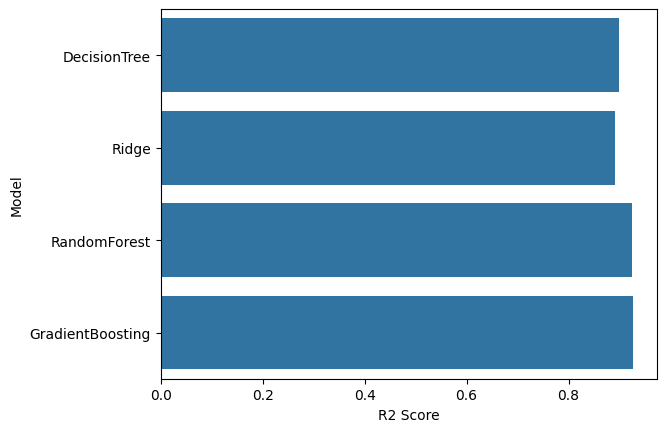

In [37]:
sns.barplot(x="R2 Score", y="Model", data=best_models_df)
plt.show()

The best performing model based on the R² score is GradientBoosting Regressor.

In [38]:
best_gb=gb_grid.best_estimator_

In [39]:
X_test_transformed = preprocessor.transform(test)

In [40]:
test_preds1=best_gb.predict(X_test_transformed)

In [41]:
print(test_preds1[:5])

[17.43832896 26.0031135  25.726711   22.20867616 14.93978851]


In [42]:
submission = pd.DataFrame({
    "total_amount": test_preds1
})
submission = submission.reset_index()
submission = submission.rename(columns={"index":"id"})


In [43]:
submission.head()

,id,total_amount
0,0,17.438329
1,1,26.003113
2,2,25.726711
3,3,22.208676
4,4,14.939789


In [44]:
submission.to_csv("submission.csv",index=False)